**NOTE: Please use the tree image saved in the folder module 5. We are explaining everything using that image only.**

## Importing the required libraries

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import os

## Read and display the sample dataset

In [3]:
os.chdir("/Users/sushovanmandal/Documents/code/learn-gen-ai/analyticsVidhya genAI/Foundational ML Algorithams/3. DecisionTree/Visualizing-Decision-Trees")

In [4]:
data = pd.read_csv("synergix_sample_data.csv")
data.head(30)

,Segment,Num_of_Promotions,Units_sold>1000
0,1,0.0,0
1,0,0.0,0
2,2,0.0,0
3,2,0.0,0
4,2,0.0,0
5,1,0.0,0
6,1,0.0,0
7,2,0.0,0
8,2,0.0,0
9,1,0.0,0


In [5]:
data.shape

(30, 3)

## Creating dependent and independent variables

In [6]:
# Features
X = data.drop(labels = ['Units_sold>1000'],axis=1)

In [7]:
#Target variable
y = data ['Units_sold>1000']


## Model building

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
DT_model = DecisionTreeClassifier(criterion = 'gini',  random_state = 42)

# Train the model
DT_model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Tree visualization

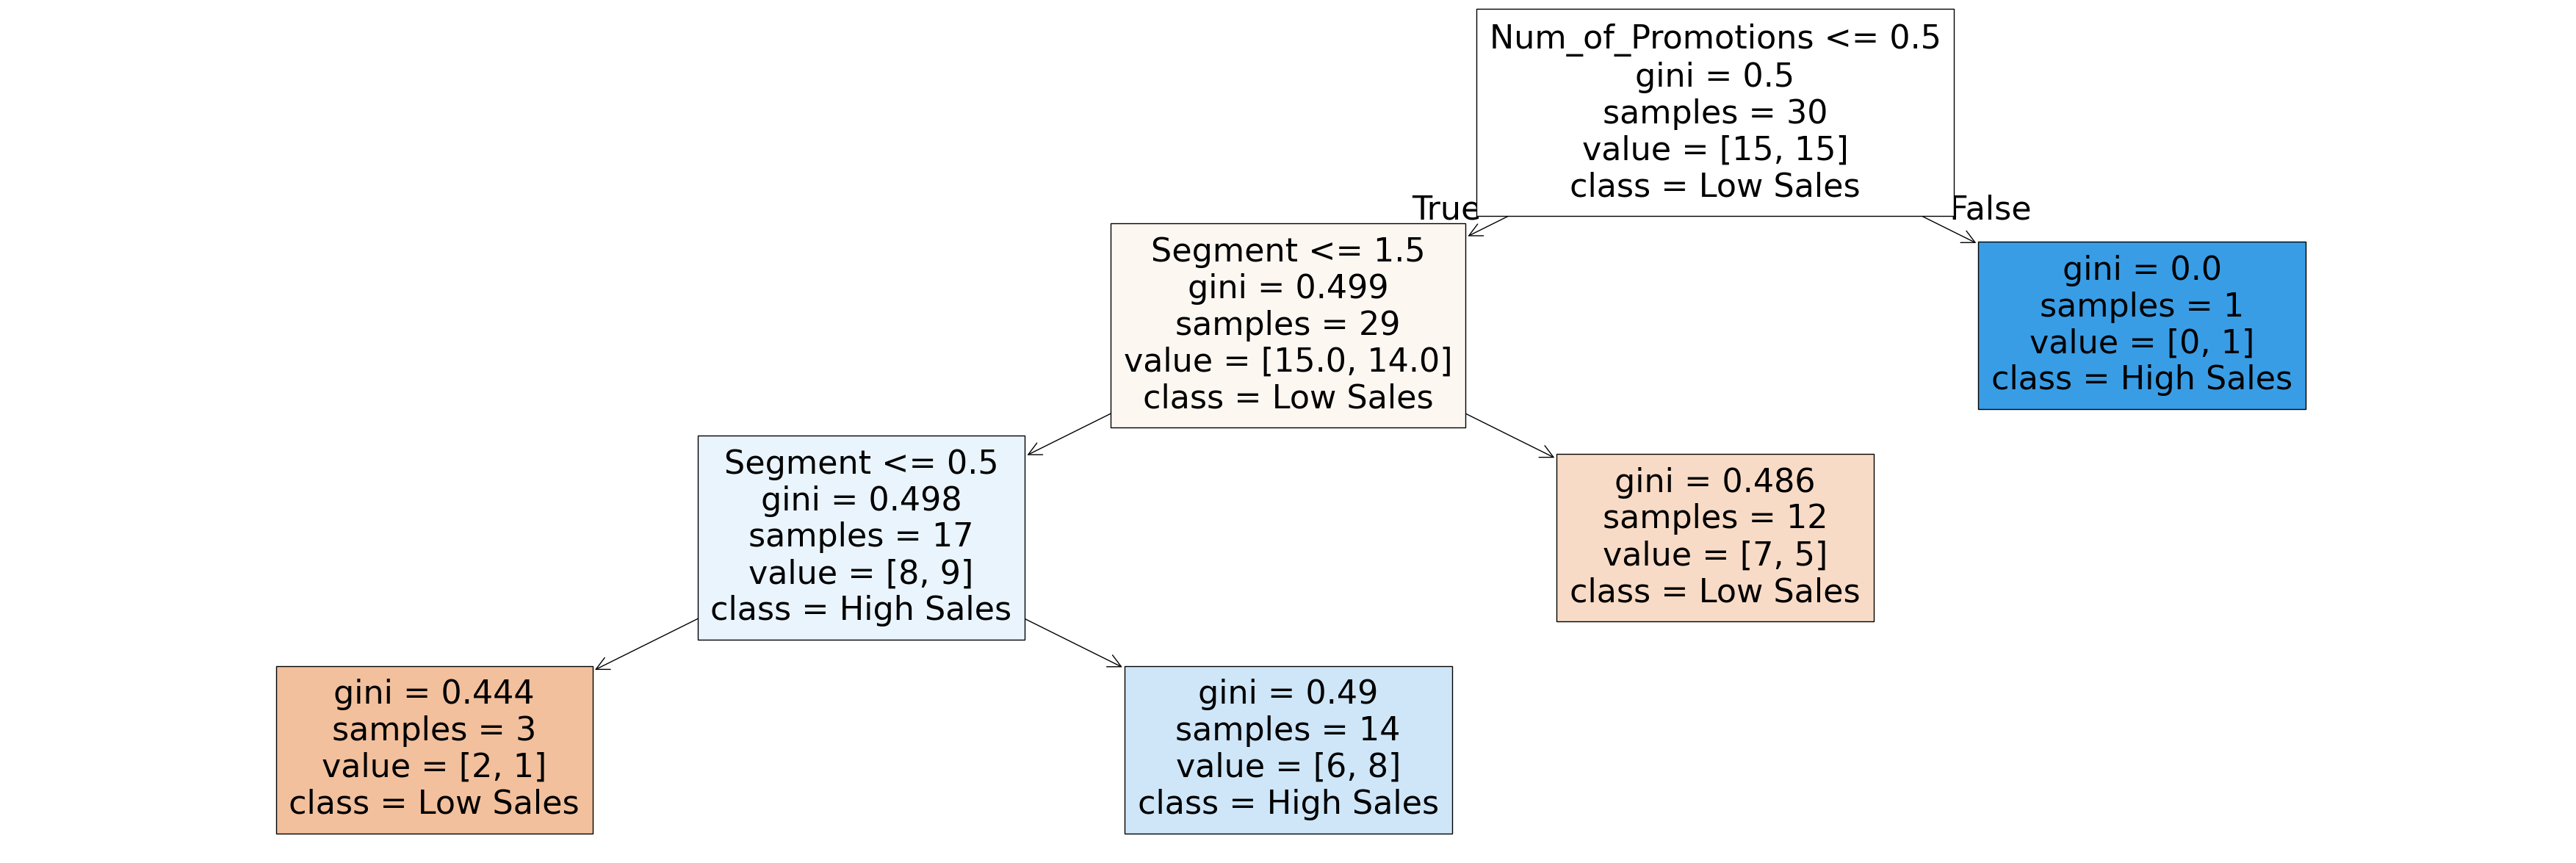

In [9]:
from matplotlib import pyplot as plt

# Visualizing the decision tree
from sklearn import tree
fig = plt.figure(figsize=(45,15))
features = X.columns
_ = tree.plot_tree(DT_model, 
                   feature_names=features,  
                   class_names=['Low Sales', 'High Sales'],
                   filled=True)


---

<img src  = "DIKHSITA TREE.png">

THIS TREE NEEDS TO BE REFERRED ALL THE TIME TILL VIDEO 4.

## Defining function to calculate the Gini Impurity

In [10]:
# Function that calculates the Gini Impurity and returns the value rounded to three decimal places

def gini(num_Class_0, num_Class_1):
    p_class_0 = num_Class_0/(num_Class_0+num_Class_1)
    p_class_1 = num_Class_1/(num_Class_0+num_Class_1)
    gini = 1-(p_class_0**2 + p_class_1**2)
    return np.round(gini, 3)

## Gini Impurity of root node

In [11]:
gini_root = gini(15,15)
gini_root

np.float64(0.5)

## Gini Impurity of child nodes

In [17]:
gini_child_node1 = gini(15,14)
gini_child_node1

np.float64(0.499)

In [18]:
gini_child_node2 = gini(0,1)
gini_child_node2

np.float64(0.0)

## Gini Impurity of a leaf node

In [19]:
gini_branch_node1 = gini(2,1)
gini_branch_node1

np.float64(0.444)

## Calculate the weighted Gini Impurity

Weighted Gini Impurity
= (Total no of samples in the first child node /Total no of samples in the parent node) x Gini Impurity of the first child node + (Total no of samples in the second child node/ Total no of samples in the parent node) x  Gini Impurity of the second child node

In [20]:
# Calculate the weighted Gini Impurity
weighted_Gini = ((29/30) * (0.499)) + ((1/30)*(0.0)) 
np.round(weighted_Gini, 3)

np.float64(0.482)

## Gini Gain

In [21]:
# GINI ROOT NODE - WEIGHTED GINI OF BRANCH NODES
0.5 - 0.482

0.018000000000000016